# Progetto Robot learning 
“Idea of yours to further improve the sim-to-real transfer in our simple scenario”


## Environment
### Pusher
#### Reward
he total reward is: ***reward*** *=* *reward_dist + reward_ctrl + reward_near*.

    - *reward_dist*:
    This reward is a measure of how far the object is from the target goal position,
    with a more negative value assigned if the object is further away from the target.
    It is $-w_{dist} \|(P_{object} - P_{target})\|_2$.
    where $w_{dist}$ is the `reward_dist_weight` (default is $1$).
    - *reward_ctrl*:
    A negative reward to penalize the pusher for taking actions that are too large.
    It is measured as the negative squared Euclidean norm of the action, i.e. as $-w_{control} \|action\|_2^2$.
    where $w_{control}$ is the `reward_control_weight` (default is $0.1$).
    - *reward_near*:
    This reward is a measure of how far the *fingertip* of the pusher (the unattached end) is from the object,
    with a more negative value assigned for when the pusher's *fingertip* is further away from the target.
    It is $-w_{near} \|(P_{fingertip} - P_{target})\|_2$.
    where $w_{near}$ is the `reward_near_weight` (default is $0.5$).

 

### hopper

 
## RL API
La differenza principale tra PPO (Proximal Policy Optimization) e SAC (Soft Actor-Critic) risiede nella loro natura on-policy/off-policy e nei meccanismi utilizzati per stabilizzare l'apprendimento:
Natura dell'algoritmo: PPO è un metodo on-policy, il che significa che richiede nuovi campioni di dati per ogni aggiornamento del gradiente, rendendolo meno efficiente nel campionamento. SAC è invece off-policy, permettendo il riutilizzo di esperienze passate tramite un replay buffer, il che lo rende molto più efficiente in termini di campioni necessari.
Obiettivo e Stabilità:
PPO ottimizza una funzione obiettivo "surrogata" e utilizza una tecnica di clipping dei rapporti di probabilità per evitare aggiornamenti troppo grandi e distruttivi della politica.
SAC si basa sul framework della massima entropia: l'agente cerca di massimizzare non solo la ricompensa attesa, ma anche l'entropia della politica (ovvero agire nel modo più casuale possibile pur avendo successo). Questo favorisce l'esplorazione e previene la convergenza prematura.
Prestazioni: SAC ha dimostrato di essere più stabile e performante in compiti di controllo continuo ad alta dimensione rispetto ad altri metodi off-policy, superando spesso anche PPO in termini di velocità di apprendimento e punteggio finale.
Quindi il sac dovrebbe essere migliore nel ambiente dell’hopper dove le masse del corpo variano casualmente, nel caso di un analisi a lungo termine perchè esplora di più così da ottenere massime reward anche in situazioni peggiori. Mentre il PPO impara più velocemente perchè segue una policy precisa senza andare ad esplorare ma basandosi solo sugli ambienti dove ha avuto risultai migliori








## Road Map
- Hopper environment
- Variazione delle masse delle masse
- Determinare quale massa è più rilevante
- Come influisce lo scostarsi dal valore di target 
- Confronto tra PPO e SAC
- test sim-to-real


## TEST HOPPER
Per il test sull'hopper siamo partiti creando 9 ideali ambienti di test variando del 5%, 25% e 55% dai valori nominali di 
- massa delle parti
- attrito tra il pamivento e i piede
- massa e attrito contemporaneamente

Abbiamo ottenuto i seguenti risultati:

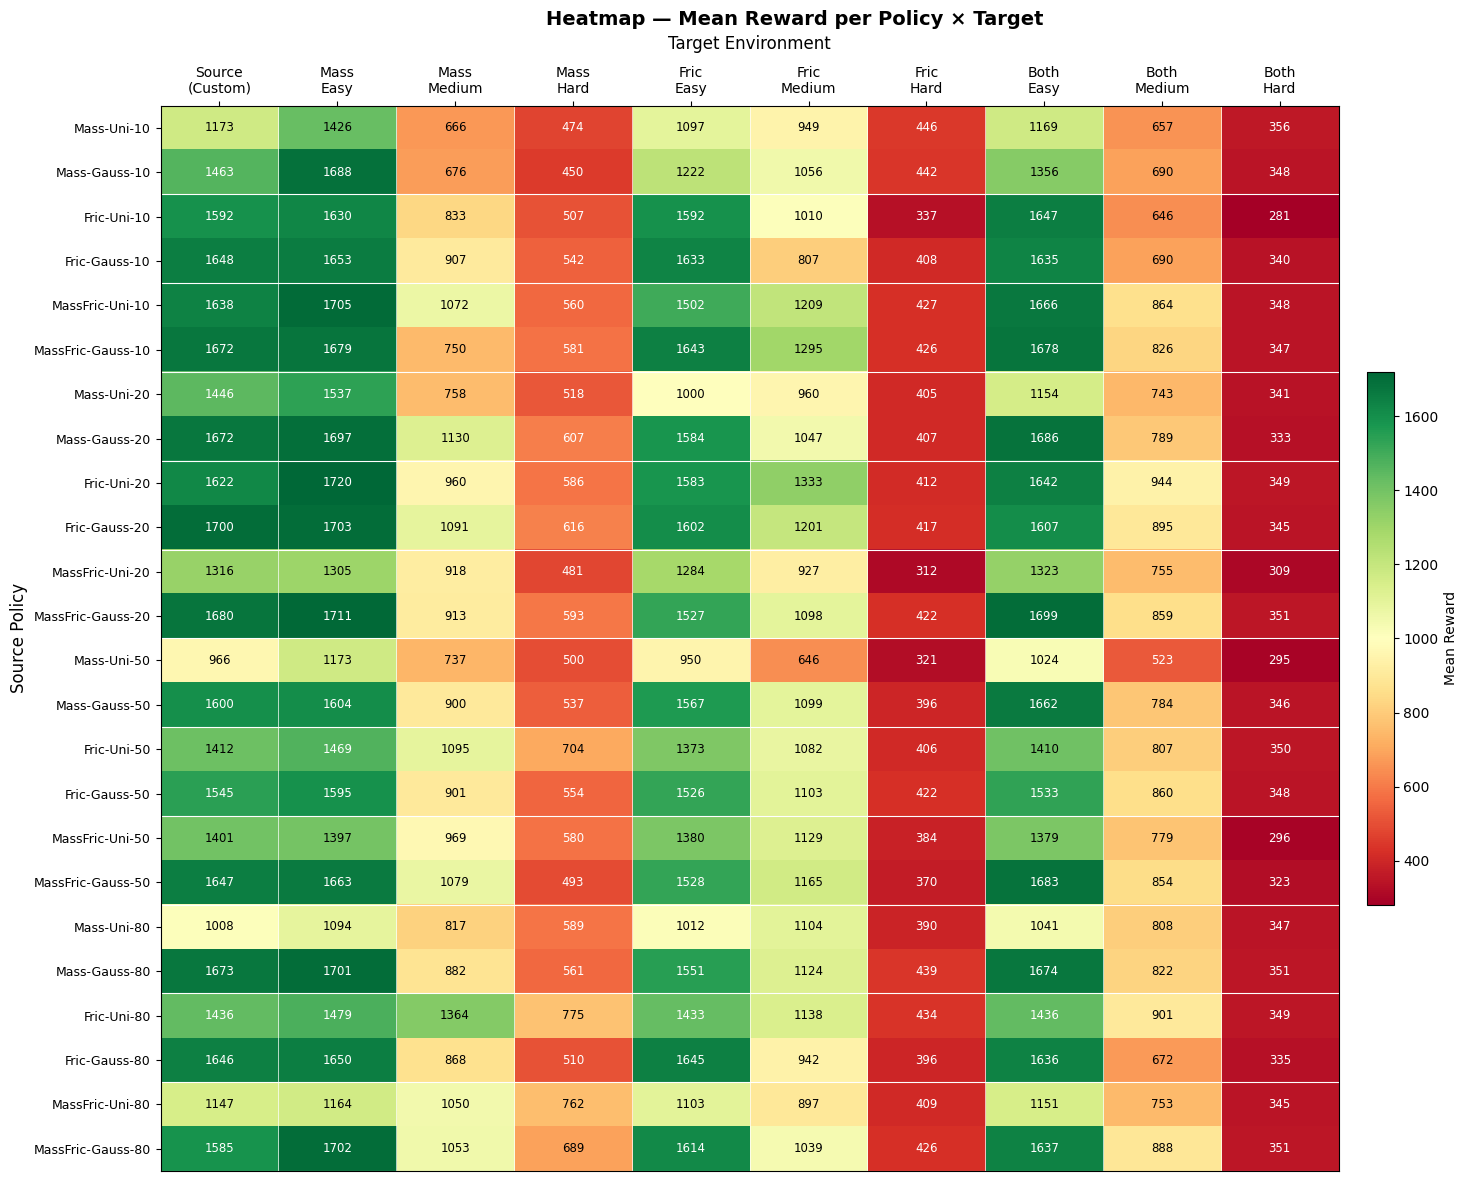

C:\Users\leona\AppData\Local\Temp\ipykernel_24604\3360406973.py:148: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\leona\AppData\Local\Temp\ipykernel_24604\3360406973.py:148: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\leona\AppData\Local\Temp\ipykernel_24604\3360406973.py:148: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\leona\AppData\Local\Temp\ipykernel_24604\3360406973.py:149: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig("plot2_scatter.png", dpi=150, bbox_inches="tight")
C:\Users\leona\AppData\Local\Temp\ipykernel_24604\3360406973.py:149: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig("plot2_scatter.png", dpi=150, bbox_inches="tight")
C:\Users\leona\AppData\Local\Temp\ipykernel_24604\3360

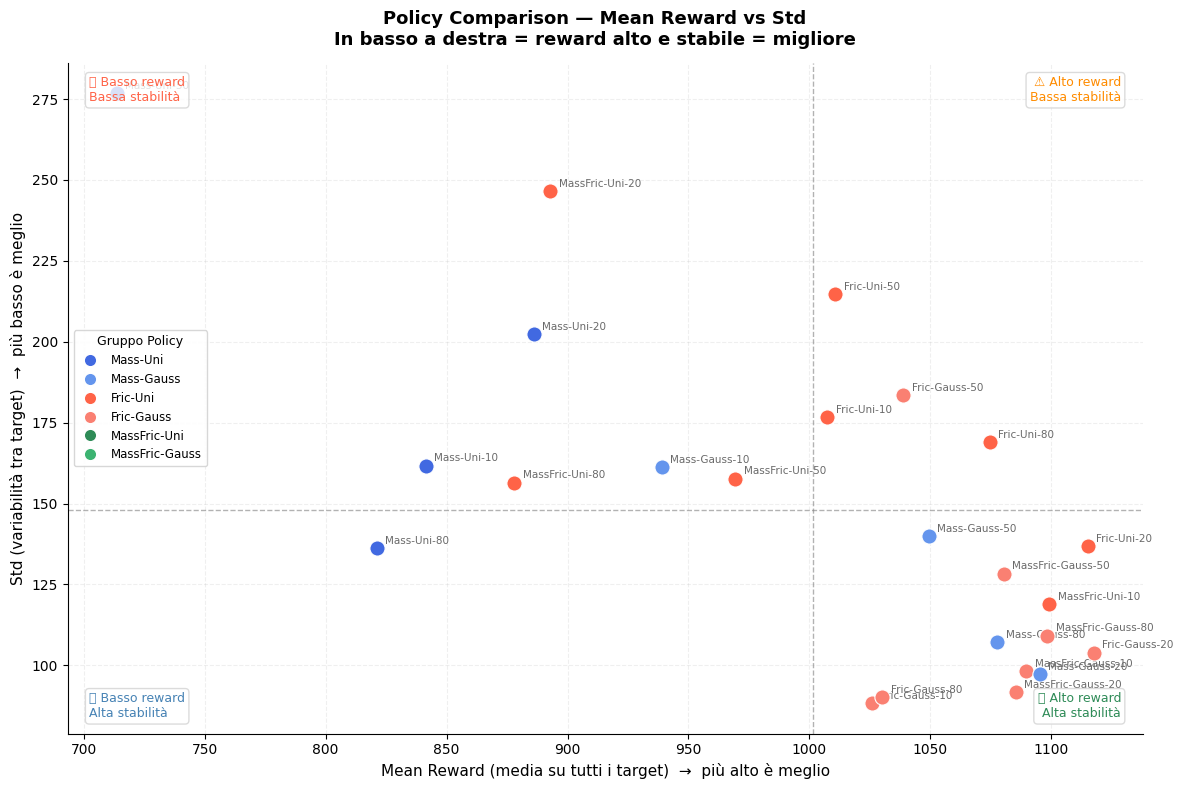

✅ Salvato: plot2_scatter.png


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

df = pd.read_csv(r"PPO/results/evaluation_matrix.csv")

targets = [
    "CustomHopper-target-v0",
    "Hopper-Target-Mass-Easy-v0",
    "Hopper-Target-Mass-Medium-v0",
    "Hopper-Target-Mass-Hard-v0",
    "Hopper-Target-Fric-Easy-v0",
    "Hopper-Target-Fric-Medium-v0",
    "Hopper-Target-Fric-Hard-v0",
    "Hopper-Target-Both-Easy-v0",
    "Hopper-Target-Both-Medium-v0",
    "Hopper-Target-Both-Hard-v0",
]
target_labels = [
    "Source\n(Custom)", "Mass\nEasy", "Mass\nMedium", "Mass\nHard",
    "Fric\nEasy", "Fric\nMedium", "Fric\nHard",
    "Both\nEasy", "Both\nMedium", "Both\nHard"
]
policy_labels = [p.replace("Hopper-", "").replace("-v1", "") for p in df["policy"].values]

matrix_mean = np.array([df[f"{t}_mean"].values for t in targets]).T   # (24, 10)
matrix_std  = np.array([df[f"{t}_std"].values  for t in targets]).T
matrix_cv   = (matrix_std / np.abs(matrix_mean)) * 100

col_means = matrix_mean.mean(axis=1)
col_cv    = matrix_cv.mean(axis=1)
row_means = matrix_mean.mean(axis=0)

rank = pd.Series(col_means).rank(ascending=False).astype(int).values

# ════════════════════════════════════════════════════════════
# PLOT 1 — HEATMAP
# ════════════════════════════════════════════════════════════
fig1, ax = plt.subplots(figsize=(16, 12))

vmin, vmax = matrix_mean.min(), matrix_mean.max()
im = ax.imshow(matrix_mean, aspect="auto", cmap="RdYlGn",
               norm=mcolors.Normalize(vmin=vmin, vmax=vmax))

for i in range(len(policy_labels)):
    for j in range(len(target_labels)):
        val = matrix_mean[i, j]
        norm_val = (val - vmin) / (vmax - vmin)
        txt_color = "black" if 0.25 < norm_val < 0.80 else "white"
        ax.text(j, i, f"{val:.0f}", ha="center", va="center",
                fontsize=8.5, color=txt_color)

for y in np.arange(1.5, len(policy_labels), 2):
    ax.axhline(y, color="white", linewidth=0.8)
for x in np.arange(0.5, len(target_labels), 1):
    ax.axvline(x, color="white", linewidth=0.5)

ax.set_xticks(range(len(target_labels)))
ax.set_xticklabels(target_labels, fontsize=10)
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")
ax.set_xlabel("Target Environment", fontsize=12, labelpad=12)
ax.set_yticks(range(len(policy_labels)))
ax.set_yticklabels(policy_labels, fontsize=9)
ax.set_ylabel("Source Policy", fontsize=12)

cbar = plt.colorbar(im, ax=ax, shrink=0.5, pad=0.02)
cbar.set_label("Mean Reward", fontsize=10)

fig1.suptitle("Heatmap — Mean Reward per Policy × Target", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot1_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()



# ════════════════════════════════════════════════════════════
# PLOT 2 — SCATTER: Mean Reward vs Std
# ════════════════════════════════════════════════════════════
col_std = matrix_std.mean(axis=1)

fig2, ax = plt.subplots(figsize=(12, 8))

group_colors = {
    "Mass-Uni":       "royalblue",
    "Mass-Gauss":     "cornflowerblue",
    "Fric-Uni":       "tomato",
    "Fric-Gauss":     "salmon",
    "MassFric-Uni":   "seagreen",
    "MassFric-Gauss": "mediumseagreen",
}
def get_group(label):
    for key in group_colors:
        if key in label:
            return key
    return "gray"

for i, label in enumerate(policy_labels):
    group  = get_group(label)
    color  = group_colors[group]
    ax.scatter(col_means[i], col_std[i], color=color, s=120,
               edgecolors="white", linewidth=0.8, zorder=3)
    ax.annotate(label, (col_means[i], col_std[i]),
                textcoords="offset points", xytext=(6, 3),
                fontsize=7.5, color="dimgray")

# Linee medie — dividono in 4 quadranti
ax.axvline(col_means.mean(), color="gray", linewidth=1, linestyle="--", alpha=0.6)
ax.axhline(col_std.mean(),   color="gray", linewidth=1, linestyle="--", alpha=0.6)

# Etichette quadranti
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
mx, my = col_means.mean(), col_std.mean()
pad_x = (xmax - xmin) * 0.02
pad_y = (ymax - ymin) * 0.02

ax.text(xmax - pad_x, ymin + pad_y, "🏆 Alto reward\nAlta stabilità",
        ha="right", va="bottom", fontsize=9, color="seagreen",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="lightgray", alpha=0.8))
ax.text(xmax - pad_x, ymax - pad_y, "⚠️ Alto reward\nBassa stabilità",
        ha="right", va="top",    fontsize=9, color="darkorange",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="lightgray", alpha=0.8))
ax.text(xmin + pad_x, ymin + pad_y, "📉 Basso reward\nAlta stabilità",
        ha="left",  va="bottom", fontsize=9, color="steelblue",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="lightgray", alpha=0.8))
ax.text(xmin + pad_x, ymax - pad_y, "❌ Basso reward\nBassa stabilità",
        ha="left",  va="top",    fontsize=9, color="tomato",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="lightgray", alpha=0.8))

ax.set_xlabel("Mean Reward (media su tutti i target)  →  più alto è meglio", fontsize=11)
ax.set_ylabel("Std (variabilità tra target)  →  più basso è meglio", fontsize=11)
ax.grid(alpha=0.2, linestyle="--")
ax.spines[["top", "right"]].set_visible(False)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=9, label=g)
    for g, c in group_colors.items()
]
ax.legend(handles=legend_elements, title="Gruppo Policy", fontsize=8.5,
          title_fontsize=9, loc="center left",
          framealpha=0.9, edgecolor="lightgray")

fig2.suptitle("Policy Comparison — Mean Reward vs Std\nIn basso a destra = reward alto e stabile = migliore",
              fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plot2_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Salvato: plot2_scatter.png")

### Analisi Ottimizzazione



## Test Pusher
